In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wjybuqi/weathertime-classification-with-road-images")

print("Path to dataset files:", path)

Resuming download from 471859200 bytes (10124222 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/wjybuqi/weathertime-classification-with-road-images?dataset_version_number=2 (471859200/481983422) bytes left.


100%|██████████| 460M/460M [00:00<00:00, 255MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wjybuqi/weathertime-classification-with-road-images/versions/2


In [3]:
!ls /kaggle/input/weathertime-classification-with-road-images

ls: cannot access '/kaggle/input/weathertime-classification-with-road-images': No such file or directory


In [4]:
base_path="/root/.cache/kagglehub/datasets/wjybuqi/weathertime-classification-with-road-images/versions/2"

image_dir= base_path + "/train_dataset/train_images"
json_path= base_path + "/train_dataset/train.json"

In [29]:
!ls root/.cache/kagglehub/datasets/wjybuqi/weathertime-classification-with-road-images/versions/2

ls: cannot access 'root/.cache/kagglehub/datasets/wjybuqi/weathertime-classification-with-road-images/versions/2': No such file or directory


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from collections import Counter

In [6]:
import json
import os
from PIL import Image
from torch.utils.data import Dataset

class WeatherTimeDataset(Dataset):
    def __init__(self, image_dir, json_path, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        with open(json_path, "r") as f:
            data = json.load(f)

        self.annotations = data["annotations"]

        self.time_mapping = {
            "dawn": 0,
            "morning": 1,
            "afternoon": 2,
            "dusk":3
        }

        self.weather_mapping = {
            "sunny": 0,
            "cloudy": 1,
            "rainy": 2
        }

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
      item = self.annotations[idx]

      filename = item["filename"].replace("\\", "/")

      if filename.startswith("train_images/"):
        img_path = os.path.join(os.path.dirname(self.image_dir), filename)
      else:
        img_path = os.path.join(self.image_dir, filename)

      image = Image.open(img_path).convert("RGB")

      time_label = self.time_mapping[item["period"].lower()]
      weather_label = self.weather_mapping[item["weather"].lower()]

      if self.transform:
        image = self.transform(image)

      return image, weather_label, time_label


In [7]:
class ResizeWithPadding:
    def __init__(self, target_size=(228, 228), fill=128):
        self.target_size = target_size
        self.fill = fill  # 128 = gray

    def __call__(self, img):
        w, h = img.size
        target_w, target_h = self.target_size

        # Compute scaling factor
        scale = min(target_w / w, target_h / h)
        new_w = int(w * scale)
        new_h = int(h * scale)

        # Resize image
        img = img.resize((new_w, new_h), Image.BILINEAR)

        # Create gray background
        new_img = Image.new("RGB", self.target_size, (self.fill, self.fill, self.fill))

        # Paste resized image at center
        paste_x = (target_w - new_w) // 2
        paste_y = (target_h - new_h) // 2
        new_img.paste(img, (paste_x, paste_y))

        return new_img


In [8]:
from torchvision import transforms

train_transform = transforms.Compose([
    ResizeWithPadding((228, 228),fill=128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
val_transform = transforms.Compose([
    ResizeWithPadding((228, 228), fill=128),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
import torch
from torch.utils.data import DataLoader, random_split

dataset = WeatherTimeDataset(
    image_dir=base_path + "/train_dataset/train_images",
    json_path=base_path + "/train_dataset/train.json",
    transform=train_transform
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

train_ds.dataset.transform= train_transform
val_ds.dataset.transform = val_transform

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

In [12]:
images, weather_labels, time_labels = next(iter(train_loader))

print(images.shape)
print(weather_labels[:5])
print(time_labels[:5])

torch.Size([8, 3, 228, 228])
tensor([1, 0, 0, 2, 1])
tensor([2, 1, 1, 1, 2])


In [13]:
import torch
import torch.nn as nn
import torchvision.models as models

In [14]:
class WeatherTimeResNet(nn.Module):
    def __init__(self, num_weather=3, num_time=4):
        super().__init__()

        # Load pretrained ResNet50
        self.backbone = models.resnet50(pretrained=True)

        # Remove final classification layer
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # Weather head
        self.weather_head = nn.Sequential(
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_weather)
        )

        # Time head - deeper for harder task
        self.time_head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_time)
        )

    def forward(self, x):
        features = self.backbone(x)
        weather_logits = self.weather_head(features)
        time_logits = self.time_head(features)
        return weather_logits, time_logits


In [15]:

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss

        return focal_loss.mean()


class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        num_classes = logits.shape[1]

        # Softmax to get probabilities
        probs = F.softmax(logits, dim=1)  # [batch, num_classes]

        # One-hot encode targets
        targets_one_hot = F.one_hot(targets, num_classes).float()  # [batch, num_classes]

        # Compute dice per class
        dice_scores = []
        for class_idx in range(num_classes):
            pred_class = probs[:, class_idx]  # [batch]
            target_class = targets_one_hot[:, class_idx]  # [batch]

            intersection = (pred_class * target_class).sum()
            union = pred_class.sum() + target_class.sum()

            dice = (2. * intersection + self.smooth) / (union + self.smooth)
            dice_scores.append(dice)

        # Average dice across classes and return loss
        mean_dice = torch.stack(dice_scores).mean()
        return 1 - mean_dice

In [16]:
def compute_weights(train_loader, device):
    """Compute balanced class weights for weather and time tasks"""

    print("Computing class weights...")

    # Collect all labels
    all_weather_labels = []
    all_time_labels = []

    for _, weather_labels, time_labels in train_loader:
        all_weather_labels.extend(weather_labels.numpy())
        all_time_labels.extend(time_labels.numpy())

    all_weather_labels = np.array(all_weather_labels)
    all_time_labels = np.array(all_time_labels)

    # Weather weights
    weather_classes = np.unique(all_weather_labels)
    weather_weights = compute_class_weight(
        class_weight='balanced',
        classes=weather_classes,
        y=all_weather_labels
    )

    # Time weights
    time_classes = np.unique(all_time_labels)
    time_weights = compute_class_weight(
        class_weight='balanced',
        classes=time_classes,
        y=all_time_labels
    )

    # Soften time weights (sqrt) to avoid extreme values
    time_weights_softened = np.sqrt(time_weights)

    # Convert to tensors
    weather_weights_tensor = torch.tensor(weather_weights, dtype=torch.float).to(device)
    time_weights_tensor = torch.tensor(time_weights_softened, dtype=torch.float).to(device)

    # Print info
    print("\nClass Distribution:")
    print("Weather:", Counter(all_weather_labels))
    print("Time:", Counter(all_time_labels))

    print("\nWeather Weights:", weather_weights)
    print("Time Weights (original):", time_weights)
    print("Time Weights (softened):", time_weights_softened)

    return weather_weights_tensor, time_weights_tensor

In [17]:
def setup_loss_functions(weather_weights, time_weights, device):
    """Setup focal + dice loss for both tasks"""

    # Create loss instances
    weather_focal = FocalLoss(alpha=weather_weights, gamma=2.0)
    time_focal = FocalLoss(alpha=time_weights, gamma=2.0)

    weather_dice = DiceLoss()
    time_dice = DiceLoss()

    # Combined loss functions
    def combined_loss_weather(logits, targets):
        fl = weather_focal(logits, targets)
        dl = weather_dice(logits, targets)
        return fl + 0.3 * dl

    def combined_loss_time(logits, targets):
        fl = time_focal(logits, targets)
        dl = time_dice(logits, targets)
        return fl + 0.5 * dl

    return combined_loss_weather, combined_loss_time

In [18]:
def train_one_epoch(model, loader, optimizer, loss_weather_fn, loss_time_fn,
                    lambda_time, device):
    """Train for one epoch"""
    model.train()

    total_loss = 0
    weather_correct = 0
    time_correct = 0
    total = 0

    for images, weather_labels, time_labels in loader:
        images = images.to(device)
        weather_labels = weather_labels.to(device)
        time_labels = time_labels.to(device)

        optimizer.zero_grad()

        weather_out, time_out = model(images)

        loss_weather = loss_weather_fn(weather_out, weather_labels)
        loss_time = loss_time_fn(time_out, time_labels)

        loss = loss_weather + lambda_time * loss_time
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        weather_correct += (weather_out.argmax(1) == weather_labels).sum().item()
        time_correct += (time_out.argmax(1) == time_labels).sum().item()
        total += images.size(0)

    return (
        total_loss / len(loader),
        weather_correct / total,
        time_correct / total
    )


def validate(model, loader, loss_weather_fn, loss_time_fn, lambda_time, device):
    model.eval()

    total_loss = 0
    weather_correct = 0
    time_correct = 0
    total = 0

    with torch.no_grad():
        for images, weather_labels, time_labels in loader:
            images = images.to(device)
            weather_labels = weather_labels.to(device)
            time_labels = time_labels.to(device)

            weather_out, time_out = model(images)

            loss_weather = loss_weather_fn(weather_out, weather_labels)
            loss_time = loss_time_fn(time_out, time_labels)

            loss = loss_weather + lambda_time * loss_time

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size

            weather_correct += (weather_out.argmax(1) == weather_labels).sum().item()
            time_correct += (time_out.argmax(1) == time_labels).sum().item()
            total += batch_size

    return (
        total_loss / total,
        weather_correct / total,
        time_correct / total
    )


In [19]:
def evaluate_f1(model, loader, device):
    model.eval()

    weather_preds = []
    weather_labels_all = []
    time_preds = []
    time_labels_all = []

    with torch.no_grad():
        for images, weather_labels, time_labels in loader:
            images = images.to(device)

            weather_out, time_out = model(images)

            w_preds = torch.argmax(weather_out, dim=1)
            t_preds = torch.argmax(time_out, dim=1)

            weather_preds.extend(w_preds.cpu().numpy())
            weather_labels_all.extend(weather_labels.numpy())

            time_preds.extend(t_preds.cpu().numpy())
            time_labels_all.extend(time_labels.numpy())

    # Compute F1 scores
    weather_f1 = f1_score(weather_labels_all, weather_preds, average="macro")
    time_f1 = f1_score(time_labels_all, time_preds, average="macro")

    # Harmonic mean
    if weather_f1 + time_f1 > 0:
        combined_f1 = (2 * weather_f1 * time_f1) / (weather_f1 + time_f1)
    else:
        combined_f1 = 0.0

    return weather_f1, time_f1, combined_f1, weather_preds, weather_labels_all, time_preds, time_labels_all



In [20]:
def train_model(model, train_loader, val_loader, device, num_epochs=20,
                lambda_time=2.0, patience=5):
    """Main training loop with early stopping"""

    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70)

    # Compute class weights
    weather_weights, time_weights = compute_weights(train_loader, device)

    # loss functions
    loss_weather_fn, loss_time_fn = setup_loss_functions(
        weather_weights, time_weights, device
    )

    # optimizer with learning rates
    optimizer = torch.optim.Adam([
        {"params": model.backbone.parameters(), "lr": 1e-5},
        {"params": model.weather_head.parameters(), "lr": 1e-3},
        {"params": model.time_head.parameters(), "lr": 1e-3}
    ])

    best_combined_f1 = 0.0
    counter = 0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):

        # Train
        train_loss, train_weather_acc, train_time_acc = train_one_epoch(
            model, train_loader, optimizer, loss_weather_fn, loss_time_fn,
            lambda_time, device
        )

        # Validate
        val_loss, val_weather_acc, val_time_acc = validate(
            model, val_loader, loss_weather_fn, loss_time_fn, lambda_time, device
        )

        # Evaluate F1
        weather_f1, time_f1, combined_f1, w_preds, w_labels, t_preds, t_labels = evaluate_f1(
            model, val_loader, device
        )

        # Print progress
        print(f"\n{'='*70}")
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"{'='*70}")
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"\nAccuracy:")
        print(f"  Weather - Train: {train_weather_acc:.4f} | Val: {val_weather_acc:.4f}")
        print(f"  Time    - Train: {train_time_acc:.4f} | Val: {val_time_acc:.4f}")
        print(f"\nF1 Scores:")
        print(f"  Weather:  {weather_f1:.4f}")
        print(f"  Time:     {time_f1:.4f}")
        print(f"  Combined: {combined_f1:.4f}")


        if epoch % 5 == 0 or epoch == 0:
            pred_dist = Counter(t_preds)
            label_dist = Counter(t_labels)
            print(f"\nTime Predictions: {dict(pred_dist)}")
            print(f"Time Actual:      {dict(label_dist)}")

        # Early stopping
        if combined_f1 > best_combined_f1:
            best_combined_f1 = combined_f1
            torch.save(model.state_dict(), best_model_path)
            print("\n✅ Improved! Model saved.")
            counter = 0
        else:
            counter += 1
            print(f"\n⏸️  Patience: {counter}/{patience}")

        if counter >= patience:
            print("\n🛑 Early stopping triggered")
            break

    print(f"\n{'='*70}")
    print(f"🎯 TRAINING COMPLETE!")
    print(f"Best Combined F1: {best_combined_f1:.4f}")
    print(f"{'='*70}")

    return best_model_path



# 8. FINAL EVALUATION


def final_evaluation(model, val_loader, device):
    """Detailed evaluation after training"""

    print("\n" + "="*70)
    print("FINAL EVALUATION")
    print("="*70)

    weather_f1, time_f1, combined_f1, w_preds, w_labels, t_preds, t_labels = evaluate_f1(
        model, val_loader, device
    )

    print(f"\n📊 F1 SCORES:")
    print(f"  Weather:  {weather_f1:.4f}")
    print(f"  Time:     {time_f1:.4f}")
    print(f"  Combined: {combined_f1:.4f}")


    weather_f1_per_class = f1_score(w_labels, w_preds, average=None)
    time_f1_per_class = f1_score(t_labels, t_preds, average=None)

    print(f"\n📈 PER-CLASS F1:")
    print("\nWeather:")
    print(f"  Sunny (0):  {weather_f1_per_class[0]:.4f}")
    print(f"  Cloudy (1): {weather_f1_per_class[1]:.4f}")
    print(f"  Rainy (2):  {weather_f1_per_class[2]:.4f}")

    print("\nTime:")
    print(f"  Dawn (0):      {time_f1_per_class[0]:.4f}")
    print(f"  Morning (1):   {time_f1_per_class[1]:.4f}")
    print(f"  Afternoon (2): {time_f1_per_class[2]:.4f}")
    print(f"  Dusk (3):      {time_f1_per_class[3]:.4f}")


    print("\n🔢 TIME CONFUSION MATRIX:")
    print("Rows = Actual, Columns = Predicted")
    print("           Dawn  Morn  Aftn  Dusk")
    cm = confusion_matrix(t_labels, t_preds)
    for i, row_name in enumerate(['Dawn    ', 'Morning ', 'Afternoon', 'Dusk    ']):
        print(f"{row_name}  {cm[i]}")


    print("\n📋 TIME CLASSIFICATION REPORT:")
    print(classification_report(t_labels, t_preds,
                              target_names=['Dawn', 'Morning', 'Afternoon', 'Dusk'],
                              digits=4))


# 9. USAGE EXAMPLE (in notebook, you would use your loaders)


if __name__ == "__main__":
    """
    Example usage - replace with your actual data loaders
    """


    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")


    model = WeatherTimeResNet(num_weather=3, num_time=4)
    model = model.to(device)


    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 211MB/s]


In [21]:
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

In [22]:
best_model_path = train_model(
         model, train_loader, val_loader, device,
         num_epochs=20,
         lambda_time=2.0,  # Weight for time task
         patience=5
     )


STARTING TRAINING
Computing class weights...

Class Distribution:
Weather: Counter({np.int64(1): 897, np.int64(0): 709, np.int64(2): 474})
Time: Counter({np.int64(1): 1306, np.int64(2): 650, np.int64(3): 95, np.int64(0): 29})

Weather Weights: [0.97790315 0.77294686 1.46272855]
Time Weights (original): [17.93103448  0.39816233  0.8         5.47368421]
Time Weights (softened): [4.23450522 0.63100105 0.89442719 2.33959061]

Epoch [1/20]
Train Loss: 2.3505 | Val Loss: 2.0659

Accuracy:
  Weather - Train: 0.6062 | Val: 0.8519
  Time    - Train: 0.5543 | Val: 0.5904

F1 Scores:
  Weather:  0.8485
  Time:     0.1856
  Combined: 0.3046

Time Predictions: {np.int64(1): 520}
Time Actual:      {np.int64(2): 179, np.int64(1): 307, np.int64(0): 5, np.int64(3): 29}

✅ Improved! Model saved.

Epoch [2/20]
Train Loss: 1.7402 | Val Loss: 1.4767

Accuracy:
  Weather - Train: 0.8317 | Val: 0.9000
  Time    - Train: 0.5808 | Val: 0.7058

F1 Scores:
  Weather:  0.9030
  Time:     0.6694
  Combined: 0.768

In [23]:
model.load_state_dict(torch.load(best_model_path))
final_evaluation(model, val_loader, device)



FINAL EVALUATION

📊 F1 SCORES:
  Weather:  0.9418
  Time:     0.8312
  Combined: 0.8830

📈 PER-CLASS F1:

Weather:
  Sunny (0):  0.9388
  Cloudy (1): 0.9365
  Rainy (2):  0.9500

Time:
  Dawn (0):      0.8889
  Morning (1):   0.9006
  Afternoon (2): 0.8466
  Dusk (3):      0.6885

🔢 TIME CONFUSION MATRIX:
Rows = Actual, Columns = Predicted
           Dawn  Morn  Aftn  Dusk
Dawn      [4 0 1 0]
Morning   [  0 290   7  10]
Afternoon  [  0  40 138   1]
Dusk      [ 0  7  1 21]

📋 TIME CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Dawn     1.0000    0.8000    0.8889         5
     Morning     0.8605    0.9446    0.9006       307
   Afternoon     0.9388    0.7709    0.8466       179
        Dusk     0.6562    0.7241    0.6885        29

    accuracy                         0.8712       520
   macro avg     0.8639    0.8099    0.8312       520
weighted avg     0.8774    0.8712    0.8701       520



In [24]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

In [25]:
class WeatherTimeResNet(nn.Module):
    def __init__(self, num_weather=3, num_time=4):
        super().__init__()

        self.backbone = models.resnet50(pretrained=True)

        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.weather_head = nn.Sequential(
            nn.Linear(num_features,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,num_weather)
        )

        self.time_head = nn.Sequential(
            nn.Linear(2048,512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256,num_time)
        )

    def forward(self,x):
        features = self.backbone(x)
        weather_logits = self.weather_head(features)
        time_logits = self.time_head(features)
        return weather_logits, time_logits

In [26]:
model = WeatherTimeResNet()

model.load_state_dict(torch.load("best_model.pth", map_location="cpu"))

model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


WeatherTimeResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(

In [27]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [28]:
weather_classes = ["cloudy","rainy","sunny"]

time_classes = ["morning","afternoon","evening","night"]

In [30]:
import os

test_folder = base_path+"/test_dataset/test_images"

for img in os.listdir(test_folder):

    path = os.path.join(test_folder, img)

    image = Image.open(path).convert("RGB")
    image = transform(image).unsqueeze(0)

    with torch.no_grad():
        w_out, t_out = model(image)

        w_pred = torch.argmax(w_out,1)
        t_pred = torch.argmax(t_out,1)

    print(img,
          weather_classes[w_pred.item()],
          time_classes[t_pred.item()])

00131.jpg rainy afternoon
02951.jpg cloudy evening
01991.jpg rainy night
01666.jpg sunny evening
00863.jpg rainy evening
00861.jpg rainy afternoon
01254.jpg rainy afternoon
00087.jpg rainy evening
00987.jpg rainy evening
00138.jpg cloudy evening
01528.jpg sunny afternoon
02914.jpg sunny afternoon
00869.jpg rainy evening
02409.jpg cloudy afternoon
02501.jpg rainy afternoon
02107.jpg cloudy afternoon
01089.jpg cloudy afternoon
00891.jpg cloudy afternoon
01835.jpg cloudy afternoon
02791.jpg sunny afternoon
02683.jpg sunny afternoon
00148.jpg rainy evening
02927.jpg sunny afternoon
00201.jpg cloudy afternoon
02096.jpg rainy afternoon
02521.jpg cloudy evening
00629.jpg rainy evening
02423.jpg cloudy afternoon
02097.jpg sunny afternoon
02717.jpg sunny afternoon
02431.jpg sunny afternoon
00330.jpg rainy afternoon
01890.jpg sunny evening
01344.jpg sunny evening
02950.jpg rainy afternoon
01305.jpg rainy afternoon
01278.jpg sunny afternoon
00099.jpg rainy evening
02676.jpg cloudy evening
02711.j

In [31]:
import matplotlib.pyplot as plt

def visualize_grid(test_folder, model):

    plt.figure(figsize=(10,10))

    for i, path in enumerate(test_folder):

        image = Image.open(path).convert("RGB")

        img_tensor = transform(image).unsqueeze(0)

        with torch.no_grad():
            w_out, t_out = model(img_tensor)

            w_pred = torch.argmax(w_out,1).item()
            t_pred = torch.argmax(t_out,1).item()

        plt.subplot(3,3,i+1)
        plt.imshow(image)
        plt.title(f"{weather_classes[w_pred]}, {time_classes[t_pred]}")
        plt.axis("off")

    plt.show()

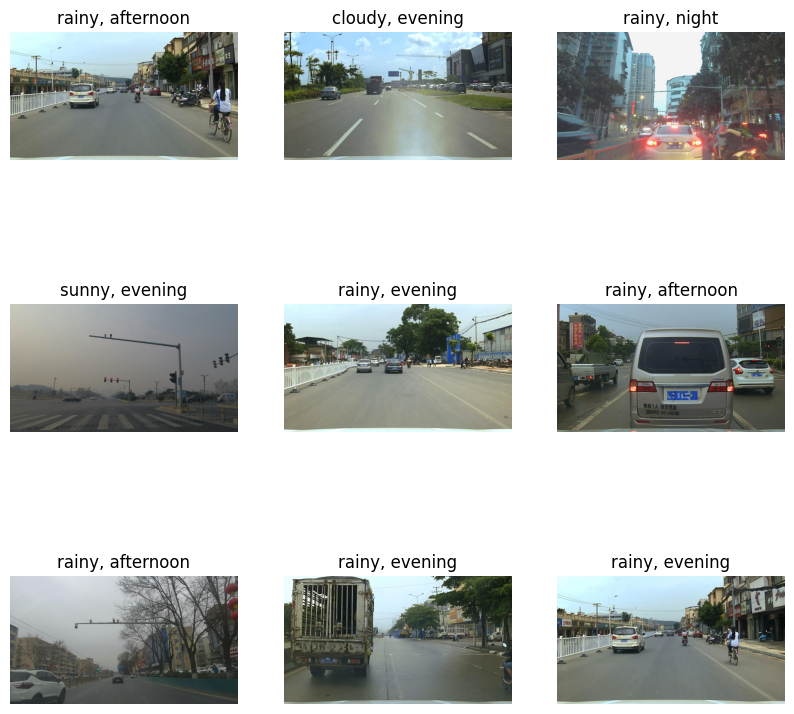

In [33]:
import os

image_files = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]
# Limit to the first 9 images for visualization in a 3x3 grid
visualize_grid(image_files[:9], model)

In [34]:
from sklearn.metrics import f1_score

In [37]:
weather_preds = []
weather_labels = []

time_preds = []
time_labels = []

model.eval()

with torch.no_grad():

    # Use val_loader for evaluation, as test_folder is a string and does not contain labels
    for images, weather, time in val_loader:

        weather_out, time_out = model(images)

        w_pred = torch.argmax(weather_out, dim=1)
        t_pred = torch.argmax(time_out, dim=1)

        weather_preds.extend(w_pred.cpu().numpy())
        weather_labels.extend(weather.cpu().numpy())

        time_preds.extend(t_pred.cpu().numpy())
        time_labels.extend(time.cpu().numpy())

In [38]:
weather_f1 = f1_score(weather_labels, weather_preds, average="macro")

print("Weather F1 Score:", weather_f1)

Weather F1 Score: 0.9417727265961089


In [39]:
time_f1 = f1_score(time_labels, time_preds, average="macro")

print("Time F1 Score:", time_f1)

Time F1 Score: 0.8311650909841027
